In [1]:
import matplotlib.pyplot as plt

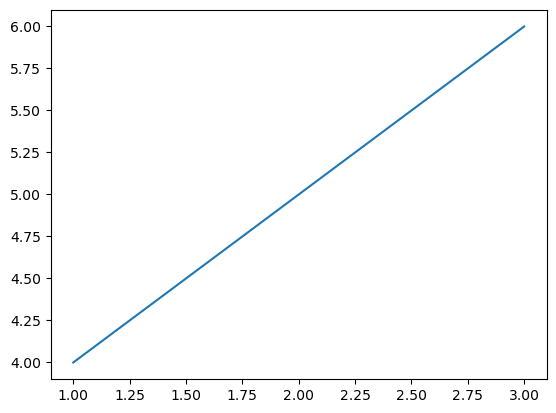

In [2]:
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('heart.csv')  # Make sure you have the heart.csv in the working directory

# Prepare data
X = df.drop('target', axis=1)
y = df['target']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train logistic regression model
model = LogisticRegression()
model.fit(X_scaled, y)

# Function to take single person input and predict
def predict_heart_disease():
    print("Enter the following health parameters:")

    # Example input features for heart.csv dataset
    # You can customize these based on your dataset features
    age = float(input("Age: "))
    sex = int(input("Sex (1 = male; 0 = female): "))
    cp = int(input("Chest pain type (0-3): "))
    trestbps = float(input("Resting blood pressure: "))
    chol = float(input("Serum cholesterol in mg/dl: "))
    fbs = int(input("Fasting blood sugar > 120 mg/dl (1 = true; 0 = false): "))
    restecg = int(input("Resting electrocardiographic results (0-2): "))
    thalach = float(input("Maximum heart rate achieved: "))
    exang = int(input("Exercise induced angina (1 = yes; 0 = no): "))
    oldpeak = float(input("ST depression induced by exercise: "))
    slope = int(input("Slope of the peak exercise ST segment (0-2): "))
    ca = int(input("Number of major vessels (0-3) colored by fluoroscopy: "))
    thal = int(input("Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect): "))

    # Create numpy array for input
    person_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg,
                             thalach, exang, oldpeak, slope, ca, thal]])

    # Scale input data using previously fitted scaler
    person_data_scaled = scaler.transform(person_data)

    # Predict probability
    prob = model.predict_proba(person_data_scaled)[0]

    print("\nPrediction:")
    print(f"Probability of NO heart disease: {prob[0]:.2f}")
    print(f"Probability of heart disease: {prob[1]:.2f}")

    # Visualize prediction
    labels = ['No Heart Disease', 'Heart Disease']
    plt.bar(labels, prob, color=['green', 'red'])
    plt.title('Heart Disease Prediction Probability')
    plt.ylim([0,1])
    plt.show()

# Run prediction function
predict_heart_disease()

Enter the following health parameters:


--- Initial Data Inspection ---
|   age |   sex |   cp |   trestbps |   chol |   fbs |   restecg |   thalach |   exang |   oldpeak |   slope |   ca |   thal |   target |
|------:|------:|-----:|-----------:|-------:|------:|----------:|----------:|--------:|----------:|--------:|-----:|-------:|---------:|
|    63 |     1 |    3 |        145 |    233 |     1 |         0 |       150 |       0 |       2.3 |       0 |    0 |      1 |        1 |
|    37 |     1 |    2 |        130 |    250 |     0 |         1 |       187 |       0 |       3.5 |       0 |    0 |      2 |        1 |
|    41 |     0 |    1 |        130 |    204 |     0 |         0 |       172 |       0 |       1.4 |       2 |    0 |      2 |        1 |
|    56 |     1 |    1 |        120 |    236 |     0 |         1 |       178 |       0 |       0.8 |       2 |    0 |      2 |        1 |
|    57 |     0 |    0 |        120 |    354 |     0 |         1 |       163 |       1 |       0.6 |       2 |    0 |      2 |        1 |

D

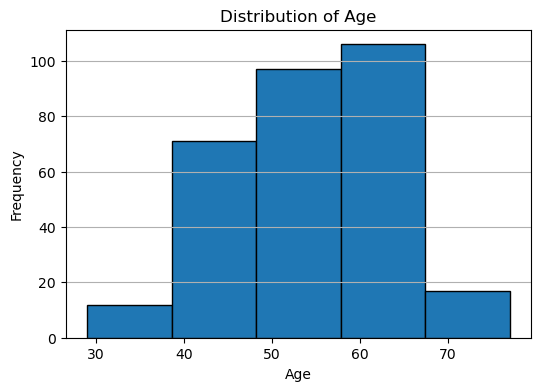

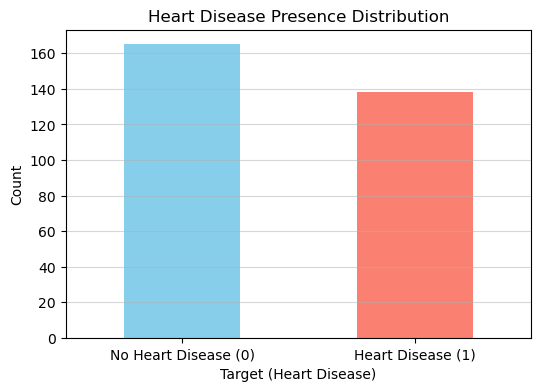

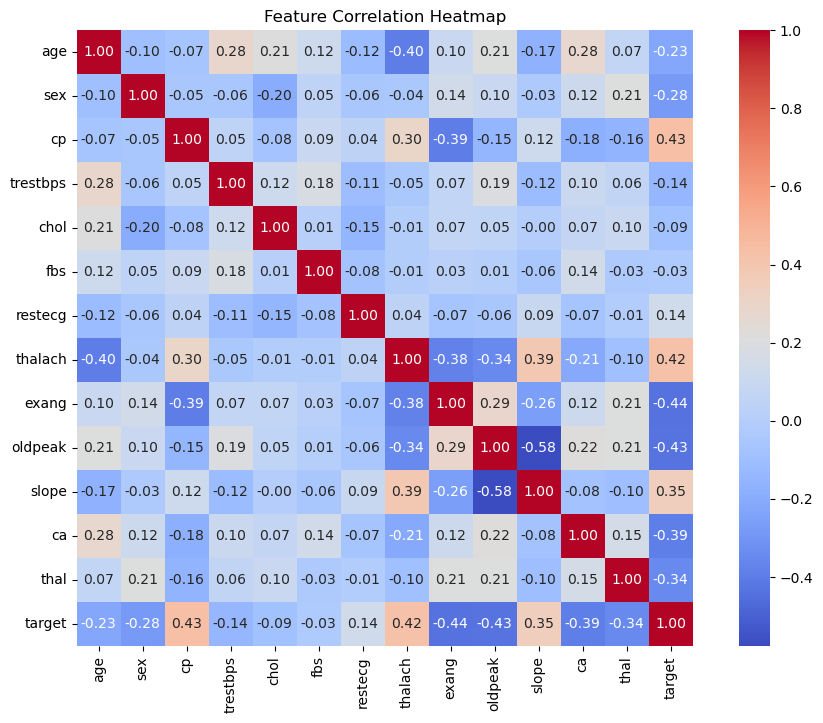


--- Model Evaluation ---
Accuracy Score: 80.33%

Confusion Matrix:
[[19  9]
 [ 3 30]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. Load the dataset ---
df = pd.read_csv('heart.csv')

print("--- Initial Data Inspection ---")
print(df.head().to_markdown(index=False))
print("\nDataset Info:")
df.info()

# --- 2. Data Visualization ---

# Age distribution histogram
plt.figure(figsize=(6, 4))
plt.hist(df['age'], bins=5, edgecolor='black', alpha=1)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=1)
plt.show()

# Target value count bar chart
target_counts = df['target'].value_counts()
target_counts.index = ['No Heart Disease (0)', 'Heart Disease (1)']

plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Heart Disease Presence Distribution')
plt.xlabel('Target (Heart Disease)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.show()

# --- 3. Prepare data for prediction ---

# Features and target
X = df.drop('target', axis=1)
y = df['target']

# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 4. Train Logistic Regression model ---
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# --- 5. Evaluate the model ---
y_pred = model.predict(X_test_scaled)

print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))